# Quickstart

This is the 10-minute tour of `brainmass`. By the end you will have, using only the
**high-level API**:

1. picked a model and run it through the {class}`~brainmass.Simulator`,
2. plotted the result with {mod}`brainmass.viz`,
3. added noise in a single line,
4. wired two regions into a delay-coupled {class}`~brainmass.Network` from a bundled connectome, and
5. **fit a parameter by gradient descent** with the {class}`~brainmass.Fitter` against a bundled signal.

No hand-written integration loops — the `Simulator`/`Network`/`Fitter` objects own the
`brainstate.transform` machinery so you focus on the model.

:::{note}
The integration time step `dt` is a **unit-aware quantity** (`0.1 * u.ms`), passed to the
`Simulator` — it is not a model argument. Quantities flow through brainmass via
[`brainunit`](https://github.com/chaobrain/brainunit), so `u.ms`, `u.mm`, … keep your
numbers physically meaningful.
:::

In [1]:
import brainmass
import braintools
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
from brainstate.nn import Param

# `dt` is a global, set once through the environment. The Simulator also takes an
# explicit dt= below; setting it here lets delay-buffer sizing work when we build a
# Network (its conduction delays are measured in dt-steps at construction time).
brainstate.environ.set(dt=0.1 * u.ms)

brainmass.__version__

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


'0.0.6'

## 1. Pick a model and run it

A brainmass model is a `*Step` object — one update step of a neural-mass equation, sized
for `in_size` regions. We pick the {class}`~brainmass.HopfStep` oscillator in its
limit-cycle regime (`a > 0`) and hand it to a {class}`~brainmass.Simulator`. One
`.run(duration, monitors=...)` call sets `dt`, initialises the state, steps the model,
and returns the stacked trajectories as a plain dict (plus a `'ts'` time axis).

In [2]:
node = brainmass.HopfStep(in_size=1, a=0.25, w=0.3)

sim = brainmass.Simulator(node, dt=0.1 * u.ms)
res = sim.run(200.0 * u.ms, monitors=["x", "y"], transient=20.0 * u.ms)

print("recorded keys:", list(res))
print("x trajectory shape (steps, regions):", res["x"].shape)
print("time axis:", res["ts"][:3], "...", res["ts"][-1])

recorded keys: ['x', 'y', 'ts']
x trajectory shape (steps, regions): (1800, 1)
time axis: [20.1 20.2 20.3] ms ... 200. ms


## 2. Plot it with `brainmass.viz`

{mod}`brainmass.viz` collects thin, matplotlib-based helpers (install the `[viz]` extra).
{func}`~brainmass.viz.plot_timeseries` takes the trajectory and the time axis directly;
{func}`~brainmass.viz.plot_phase_portrait` plots one state variable against another, which
for a Hopf node traces out its circular limit cycle.

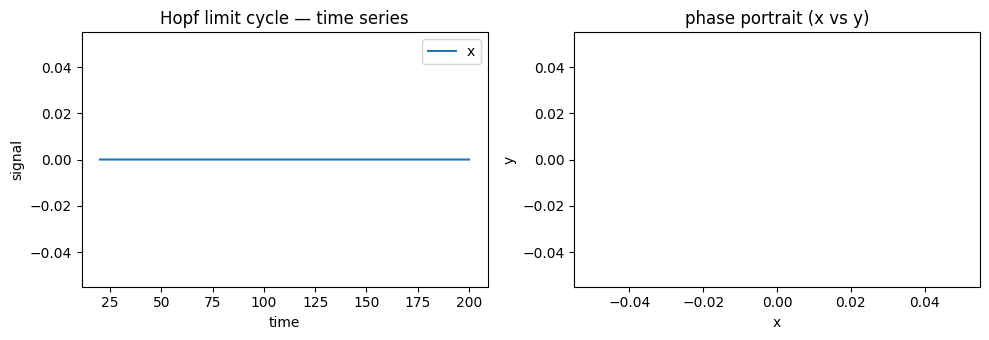

In [3]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

brainmass.viz.plot_timeseries(res["x"], ts=res["ts"], labels=["x"], ax=ax1)
ax1.set_title("Hopf limit cycle — time series")

brainmass.viz.plot_phase_portrait(res["x"][:, 0], res["y"][:, 0], ax=ax2)
ax2.set_title("phase portrait (x vs y)")

fig.tight_layout()

## 3. Add noise in one line

Real activity fluctuates. Attach an Ornstein–Uhlenbeck process
({class}`~brainmass.OUProcess`) to a state component when you build the model — the noise
is added automatically inside `update()`, and the `Simulator` call is unchanged. Here we
drop the node *below* the bifurcation (`a < 0`, a stable focus) so the dynamics are noise
driven rather than a clean limit cycle.

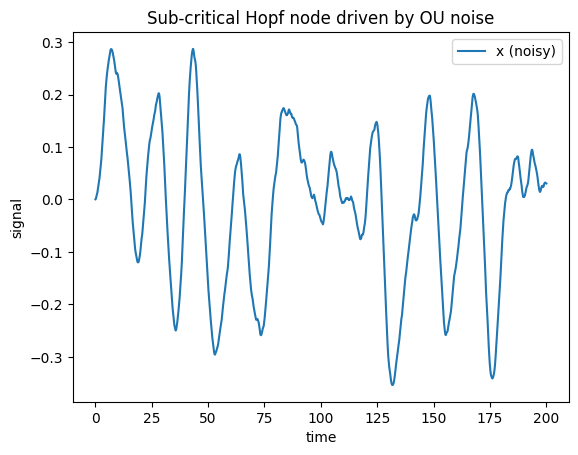

In [4]:
noisy = brainmass.HopfStep(
    in_size=1, a=-0.05, w=0.3,
    noise_x=brainmass.OUProcess(in_size=1, sigma=0.1, tau=20.0 * u.ms),  # <- one line
)

res_noisy = brainmass.Simulator(noisy, dt=0.1 * u.ms).run(200.0 * u.ms, monitors=["x"])

ax = brainmass.viz.plot_timeseries(res_noisy["x"], ts=res_noisy["ts"], labels=["x (noisy)"])
ax.set_title("Sub-critical Hopf node driven by OU noise");

## 4. A two-region network (with a bundled connectome)

{mod}`brainmass.datasets` ships small, license-clean example data so every notebook runs
with **no download**. `load_dataset('example_connectome')` returns a typed
{class}`~brainmass.datasets.Connectome` with structural `weights` and unit-aware
`distances` (in `u.mm`).

We take the first two regions and hand them to a {class}`~brainmass.Network`. The network
zeros the self-connections, turns `distance / speed` into conduction **delays**, and feeds
a diffusive coupling current back into the node — the same wiring you would otherwise write
by hand. The `Simulator` then drives the whole network exactly as it drove the single node.

connectome: (8, 8) regions: [np.str_('R0'), np.str_('R1'), np.str_('R2'), np.str_('R3'), np.str_('R4'), np.str_('R5'), np.str_('R6'), np.str_('R7')]


network output shape (steps, regions): (1800, 2)


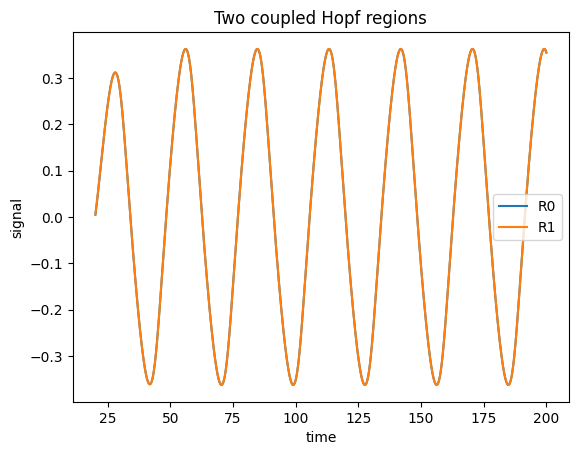

In [5]:
conn = brainmass.datasets.load_dataset("example_connectome")
print("connectome:", conn.weights.shape, "regions:", list(conn.labels))

# Use the first two regions as a minimal 2-node network.
W = conn.weights[:2, :2]
D = conn.distances[:2, :2]

two_nodes = brainmass.HopfStep(in_size=2, a=0.2, w=0.3)
net = brainmass.Network(
    two_nodes,
    conn=W,
    distance=D,
    speed=10.0 * u.mm / u.ms,   # delays = distance / speed
    coupling="diffusive",
    coupled_var="x",
    k=0.5,                       # global coupling strength
)

res_net = brainmass.Simulator(net, dt=0.1 * u.ms).run(
    200.0 * u.ms,
    monitors=lambda m: m.node.x.value,   # read the coupled node state each step
    transient=20.0 * u.ms,
)
print("network output shape (steps, regions):", res_net["output"].shape)

ax = brainmass.viz.plot_timeseries(
    res_net["output"], ts=res_net["ts"], labels=list(conn.labels[:2])
)
ax.set_title("Two coupled Hopf regions");

## 5. Fit a parameter by gradient descent

Here is brainmass's headline capability: because the whole simulation is differentiable,
you can **backprop through the ODE solve** and fit parameters with gradients instead of
grid or evolutionary search.

We use the bundled `example_signal` dataset as the target. A {class}`~brainmass.HopfStep`
in its limit cycle settles at an amplitude `~sqrt(a / beta)`, so the bifurcation parameter
`a` controls how big the oscillation is. We mark `a` trainable with `Param(..., fit=True)`,
start it too small, and let the {class}`~brainmass.Fitter` (gradient backend) drive the
simulated oscillation's amplitude to match the data.

In [6]:
# Target: the RMS amplitude of region 0 of the bundled example signal.
sig = brainmass.datasets.load_dataset("example_signal")
target0 = sig.signal[:, 0]
target_amp = jnp.asarray(float(np.sqrt(np.mean((target0 - target0.mean()) ** 2))))
print("target amplitude from example_signal:", round(float(target_amp), 4))

# Model with ONE trainable parameter: the Hopf bifurcation parameter `a`.
model = brainmass.HopfStep(
    in_size=1,
    a=Param(0.05, fit=True),   # <- the single knob the Fitter will tune
    w=0.3, beta=1.0,
    init_x=braintools.init.Constant(0.5),
)


def loss_fn(m):
    """Run the model and compare its settled amplitude to the target."""
    x = brainmass.Simulator(m, dt=0.1 * u.ms).run(
        300.0 * u.ms, monitors=["x"], transient=150.0 * u.ms
    )["x"][:, 0]
    amp = jnp.sqrt(jnp.mean((x - jnp.mean(x)) ** 2))
    return (amp - target_amp) ** 2, amp


fitter = brainmass.Fitter(model, braintools.optim.Adam(lr=0.05), loss_fn=loss_fn)
result = fitter.fit(n_steps=50)

print(result)
print(f"a:        0.05  ->  {float(result.best_params['a']):.4f}")
print(f"loss:  {result.history[0]:.4f}  ->  {result.best_loss:.5f}")
print(f"amplitude matched: {float(result.prediction):.4f}  (target {float(target_amp):.4f})")

target amplitude from example_signal: 0.7152


FitResult(backend='grad', best_loss=3.10454e-07, n_steps=50, params=[a])
a:        0.05  ->  1.0262
loss:  0.3042  ->  0.00000
amplitude matched: 0.7157  (target 0.7152)


The loss curve shows the gradient optimiser converging in a few dozen steps — no parameter
sweep required.

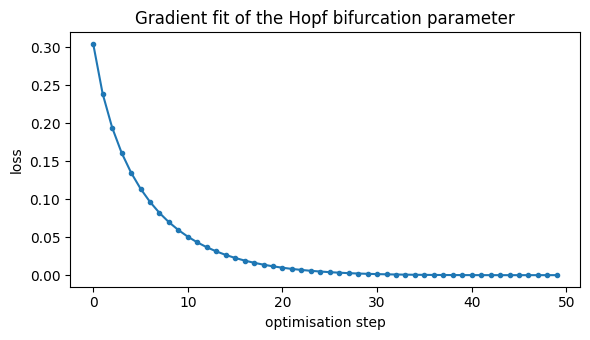

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(result.history, marker=".")
ax.set_xlabel("optimisation step")
ax.set_ylabel("loss")
ax.set_title("Gradient fit of the Hopf bifurcation parameter")
fig.tight_layout()

## Where to go next

You have run, visualised, perturbed, coupled, and *fit* a model — all through the
high-level API. To go deeper:

- {doc}`/getting_started/key_concepts` — the mental model behind `*Step` models,
  `Simulator`, `Network`, `Fitter` and units.
- The fitting story is expanded across tutorials
  {doc}`06 (gradients) </tutorials/06_fitting_with_gradients>`,
  {doc}`07 (gradient-free) </tutorials/07_gradient_free_fitting>` and
  {doc}`08 (training on tasks) </tutorials/08_training_on_tasks>`.
- {doc}`/howto/choose_a_model` — browse every model with `brainmass.list_models()`.
- {doc}`/tutorials/04_building_a_network` — full whole-brain networks.

## See also

- {doc}`/reference/orchestration` — `Simulator` / `Network` / `Fitter` API.
- {doc}`/reference/datasets` and {doc}`/reference/viz` — the bundled data and plotting helpers.
- {doc}`/reference/models` — the full model reference.